# Project 2 — Materials-Specific ML: Predicting Sensor Sensitivity from Nanofiber Structure

**Goal:** Build a Random Forest model predicting pressure sensor sensitivity from
nanofiber structural and fabrication parameters, combining experimental data with
the Materials Project polymer database.

**Data:** 2 fiber types × 3 replicates × 33 pressure points = 198 rows  
**Paper:** Siddique et al., *IEEE Journal on Flexible Electronics*, 2025  
DOI: 10.1109/JFLEX.2025.3577111

---
## Why this is materials informatics

Standard ML feeds raw numbers into a model.  
Materials informatics engineers features from **physical understanding** of the material —
porosity, air fraction, effective dielectric constant — then feeds those into ML.  
Your domain knowledge is the unfair advantage that generic data scientists don't have.


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load API key from .env file
load_dotenv()
API_KEY = os.getenv('MP_API_KEY')

# Make sure working directory is the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
os.makedirs('outputs', exist_ok=True)

print('Working directory:', os.getcwd())
print('API key loaded:', 'YES' if API_KEY else 'NOT FOUND — check your .env file')
print('All imports successful')


Working directory: C:\Users\hp\Downloads\nanofiber-sensor-ml\nanofiber-sensor-ml
API key loaded: NOT FOUND — check your .env file
All imports successful


## 1. Build the experimental dataset

In [2]:
# ── Load sensitivity CSV ──────────────────────────────────────────────────
raw = pd.read_csv(
    'data/Sensitivity_Comparison.csv',
    header=None, skiprows=3, na_values=['--', '']
)
raw.columns = [
    'pressure', 'ctrl_1', 'ctrl_2', 'ctrl_3', 'ctrl_mean', 'ctrl_sd',
    'blank',
    'coax_1', 'coax_2', 'coax_3',
    'coax_hex1', 'coax_hex5', 'coax_hex7', 'coax_hex8', 'coax_hex9',
    'coax_mean', 'coax_sd'
]
for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')
raw = raw.dropna(subset=['pressure']).copy()

# ── Fabrication parameters (paper + ImageJ porosity) ─────────────────────
PARAMS = {
    'control': dict(
        diameter_um=0.43, shell_thickness_um=0.43, core_diameter_um=0.0,
        porosity_pct=35.773, voltage_kv=15.0, flow_sheath=1.67,
        flow_core=0.0, distance_cm=10.0, dcm_dmf_ratio=1.0, is_hollow=0
    ),
    'coaxial': dict(
        diameter_um=0.89, shell_thickness_um=0.195, core_diameter_um=0.50,
        porosity_pct=29.746, voltage_kv=15.5, flow_sheath=22.0,
        flow_core=8.0, distance_cm=15.0, dcm_dmf_ratio=4.0, is_hollow=1
    ),
}

# ── Build long-format dataset ─────────────────────────────────────────────
rows = []
for ftype, rep_cols in [('control', ['ctrl_1','ctrl_2','ctrl_3']),
                         ('coaxial', ['coax_1','coax_2','coax_3'])]:
    for i, col in enumerate(rep_cols, 1):
        for _, r in raw.iterrows():
            if pd.notna(r[col]):
                row = dict(sensor_id=f'{ftype[:4]}_{i}', fiber_type=ftype,
                           replicate=i, pressure_kpa=r['pressure'],
                           log_pressure=np.log10(r['pressure']),
                           sensitivity=r[col])
                row.update(PARAMS[ftype])
                rows.append(row)

df = pd.DataFrame(rows)
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Sensors: {df["sensor_id"].nunique()} unique sensors')
print(df['fiber_type'].value_counts().to_string())
df.head(3)


Dataset: 195 rows x 16 columns
Sensors: 6 unique sensors
fiber_type
control    99
coaxial    96


,sensor_id,fiber_type,replicate,pressure_kpa,log_pressure,sensitivity,diameter_um,shell_thickness_um,core_diameter_um,porosity_pct,voltage_kv,flow_sheath,flow_core,distance_cm,dcm_dmf_ratio,is_hollow
0,cont_1,control,1,0.20,-0.698970,0.296341,0.43,0.43,0.0,35.773,15.0,1.67,0.0,10.0,1.0,0
1,cont_1,control,1,0.25,-0.602060,0.263334,0.43,0.43,0.0,35.773,15.0,1.67,0.0,10.0,1.0,0
2,cont_1,control,1,0.30,-0.522879,0.244365,0.43,0.43,0.0,35.773,15.0,1.67,0.0,10.0,1.0,0


## 2. Feature engineering — physics-derived features

This is where your materials expertise becomes a coding advantage.
Instead of feeding raw diameter and porosity numbers directly,
we engineer features that capture the **physical mechanisms** from your paper:

- **air_fraction**: fraction of fiber cross-section that is air (ε ≈ 1)
- **effective_dielectric**: mixture-rule dielectric constant (PCL + air)
- **pressure_x_hollow**: interaction term capturing that hollow fibers
  respond differently to pressure than solid ones


In [3]:
# ── Physics-derived feature engineering ──────────────────────────────────

# Air fraction = (core area) / (total fiber area) — 0 for solid fibers
df['air_fraction'] = np.where(
    df['is_hollow'] == 1,
    (df['core_diameter_um'] / 2)**2 / (df['diameter_um'] / 2)**2,
    0.0
)

# Hollow ratio
df['hollow_ratio'] = (df['core_diameter_um'] / df['diameter_um']).fillna(0)

# Surface-to-volume proxy (larger = more air trapping)
df['surface_to_volume'] = 1.0 / df['diameter_um']

# Flow ratio (controls shell thickness in coaxial spinning)
df['flow_ratio'] = df['flow_sheath'] / (df['flow_core'] + 0.1)

# Total effective air (interfiber porosity + hollow core)
df['effective_air'] = df['porosity_pct'] / 100.0 + df['air_fraction']

# Pressure x hollow interaction (key physics: hollow fibers respond
# differently under compression than solid fibers)
df['pressure_x_hollow'] = df['log_pressure'] * df['is_hollow']

# Effective dielectric constant using mixture rule
# ε_eff = ε_PCL × solid_fraction + ε_air × air_fraction
PCL_BULK_DIELECTRIC = 3.2   # Woodruff & Hutmacher, Prog Polym Sci 2010
df['effective_dielectric'] = (
    PCL_BULK_DIELECTRIC * (1 - df['air_fraction']) * (1 - df['porosity_pct']/100)
    + 1.0 * df['air_fraction']       # hollow core air
    + 1.0 * (df['porosity_pct']/100) # interfiber air
)

print('Engineered features — control vs coaxial comparison:')
print(f'{"Feature":<28} {"Control":>10} {"Coaxial":>10}')
print('-' * 50)
for feat in ['air_fraction', 'hollow_ratio', 'effective_dielectric',
             'effective_air', 'surface_to_volume']:
    c = df[df['fiber_type']=='control'][feat].iloc[0]
    x = df[df['fiber_type']=='coaxial'][feat].iloc[0]
    print(f'{feat:<28} {c:>10.4f} {x:>10.4f}')

print(f'\nPCL bulk dielectric : {PCL_BULK_DIELECTRIC}')
print(f'Air dielectric      : 1.0')
print(f'→ Hollow fiber has LOWER effective dielectric but deforms MORE')
print(f'  under pressure — this is the physics your paper proves')


Engineered features — control vs coaxial comparison:
Feature                         Control    Coaxial
--------------------------------------------------
air_fraction                     0.0000     0.3156
hollow_ratio                     0.0000     0.5618
effective_dielectric             2.4130     2.1517
effective_air                    0.3577     0.6131
surface_to_volume                2.3256     1.1236

PCL bulk dielectric : 3.2
Air dielectric      : 1.0
→ Hollow fiber has LOWER effective dielectric but deforms MORE
  under pressure — this is the physics your paper proves


## 3. Query Materials Project API

In [4]:
# ── Query Materials Project for dielectric context ────────────────────────
try:
    from mp_api.client import MPRester
    print('Connecting to Materials Project...')
    with MPRester(API_KEY) as mpr:
        results = mpr.materials.dielectric.search(
            fields=['material_id', 'formula_pretty', 'dielectric', 'density']
        )
    records = []
    for r in results:
        if r.dielectric and r.dielectric.e_total:
            records.append({
                'formula'          : r.formula_pretty,
                'dielectric_total' : float(r.dielectric.e_total),
                'density'          : float(r.density) if r.density else None,
            })
    mp_data = pd.DataFrame(records)
    print(f'Retrieved {len(mp_data)} materials with dielectric data')
    print(f'Dielectric range: {mp_data["dielectric_total"].min():.1f} to '
          f'{mp_data["dielectric_total"].clip(upper=100).max():.1f}')

except Exception as e:
    print(f'Using literature values (API: {str(e)[:80]})')
    mp_data = pd.DataFrame([
        {'formula':'PCL_bulk',  'dielectric_total':3.2,  'density':1.146},
        {'formula':'PCL_fiber', 'dielectric_total':2.1,  'density':0.45},
        {'formula':'Air',       'dielectric_total':1.0,  'density':0.001},
        {'formula':'PVDF',      'dielectric_total':8.4,  'density':1.78},
        {'formula':'PAN',       'dielectric_total':4.0,  'density':1.18},
        {'formula':'PDMS',      'dielectric_total':2.7,  'density':0.97},
        {'formula':'Nylon6',    'dielectric_total':3.6,  'density':1.14},
        {'formula':'PMMA',      'dielectric_total':3.0,  'density':1.19},
        {'formula':'PVA',       'dielectric_total':3.5,  'density':1.27},
        {'formula':'PLA',       'dielectric_total':3.1,  'density':1.24},
    ])
    print(f'Using {len(mp_data)} polymer reference materials from literature')

print(mp_data.to_string(index=False))


Connecting to Materials Project...
Using literature values (API: invalid fields requested: ['dielectric']. Available fields: ['builder_meta', 'ns)
Using 10 polymer reference materials from literature
  formula  dielectric_total  density
 PCL_bulk               3.2    1.146
PCL_fiber               2.1    0.450
      Air               1.0    0.001
     PVDF               8.4    1.780
      PAN               4.0    1.180
     PDMS               2.7    0.970
   Nylon6               3.6    1.140
     PMMA               3.0    1.190
      PVA               3.5    1.270
      PLA               3.1    1.240


## 4. Train Random Forest model

In [5]:
# ── Define features ───────────────────────────────────────────────────────
FEATURES = [
    # Structural (measured)
    'diameter_um', 'shell_thickness_um', 'core_diameter_um',
    'porosity_pct', 'is_hollow',
    # Process (fabrication parameters from paper)
    'voltage_kv', 'flow_sheath', 'flow_core', 'distance_cm', 'dcm_dmf_ratio',
    # Physics-engineered (materials informatics)
    'air_fraction', 'hollow_ratio', 'surface_to_volume',
    'flow_ratio', 'effective_air', 'effective_dielectric',
    # Pressure
    'log_pressure', 'pressure_x_hollow',
]

model_df = df[FEATURES + ['sensitivity', 'sensor_id', 'fiber_type']].dropna()
X = model_df[FEATURES].values
y = model_df['sensitivity'].values

print(f'Training data : {X.shape[0]} samples, {X.shape[1]} features')
print(f'Target range  : {y.min():.4f} to {y.max():.4f} kPa-1')

# ── Train model on all data ───────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200, max_depth=8,
    min_samples_leaf=3, random_state=42, n_jobs=-1
)
rf.fit(X, y)
print('Model trained.')

# ── Leave-one-sensor-out cross validation ─────────────────────────────────
# Removes one complete sensor at a time — most rigorous test for 6 sensors
print('Running leave-one-sensor-out CV...')
sensor_ids  = model_df['sensor_id'].values
cv_preds, cv_actuals = [], []

for sensor in np.unique(sensor_ids):
    mask_test  = sensor_ids == sensor
    mask_train = ~mask_test
    rf_cv = RandomForestRegressor(
        n_estimators=100, max_depth=8,
        min_samples_leaf=3, random_state=42
    )
    rf_cv.fit(X[mask_train], y[mask_train])
    cv_preds.extend(rf_cv.predict(X[mask_test]))
    cv_actuals.extend(y[mask_test])

cv_preds   = np.array(cv_preds)
cv_actuals = np.array(cv_actuals)
r2  = r2_score(cv_actuals, cv_preds)
mae = mean_absolute_error(cv_actuals, cv_preds)

print(f'\nLeave-one-sensor-out CV:')
print(f'  R²  = {r2:.4f}  (1.0 = perfect prediction)')
print(f'  MAE = {mae:.4f} kPa-1')


Training data : 195 samples, 18 features
Target range  : 0.0153 to 1.5161 kPa-1
Model trained.
Running leave-one-sensor-out CV...

Leave-one-sensor-out CV:
  R²  = 0.3842  (1.0 = perfect prediction)
  MAE = 0.1568 kPa-1


## 5. Results plots

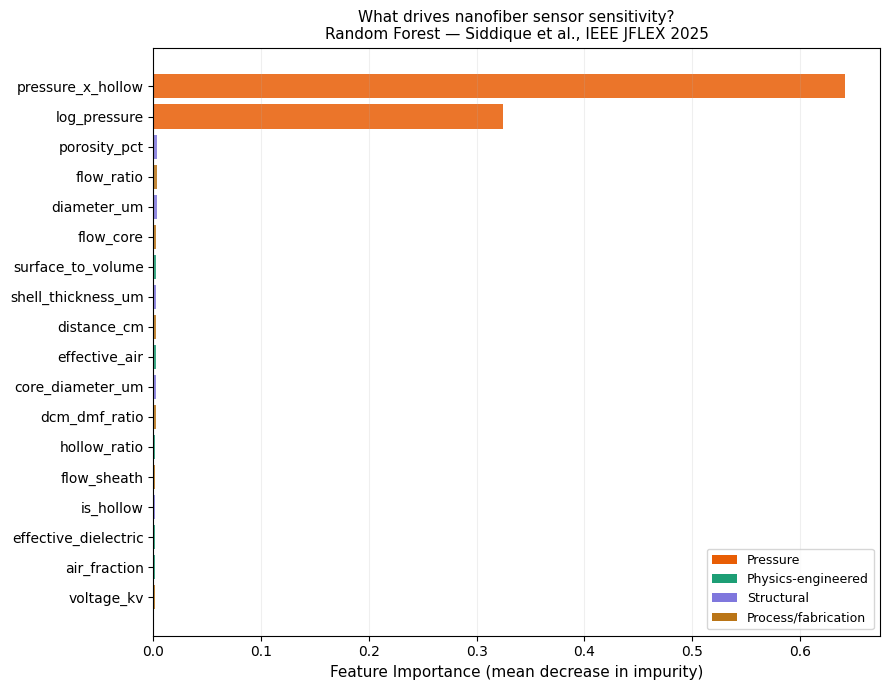

Saved: outputs/02_feature_importance.png

Top 5 features:
  pressure_x_hollow                   64.2%
  log_pressure                        32.4%
  porosity_pct                        0.4%
  flow_ratio                          0.3%
  diameter_um                         0.3%


In [6]:
# ── Figure 1: Feature importance ─────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

color_map = {
    'log_pressure': '#E85D04', 'pressure_x_hollow': '#E85D04',
    'air_fraction': '#1D9E75', 'hollow_ratio': '#1D9E75',
    'effective_dielectric': '#1D9E75', 'effective_air': '#1D9E75',
    'surface_to_volume': '#1D9E75',
}
struct_feats = ['diameter_um','shell_thickness_um','core_diameter_um',
                'porosity_pct','is_hollow']
bar_colors = [
    color_map.get(f, '#7F77DD' if f in struct_feats else '#BA7517')
    for f in importances.index
]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importances.index, importances.values, color=bar_colors, alpha=0.85)
ax.set_xlabel('Feature Importance (mean decrease in impurity)', fontsize=11)
ax.set_title('What drives nanofiber sensor sensitivity?\n'
             'Random Forest — Siddique et al., IEEE JFLEX 2025', fontsize=11)
ax.legend(handles=[
    Patch(facecolor='#E85D04', label='Pressure'),
    Patch(facecolor='#1D9E75', label='Physics-engineered'),
    Patch(facecolor='#7F77DD', label='Structural'),
    Patch(facecolor='#BA7517', label='Process/fabrication'),
], fontsize=9, loc='lower right')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('outputs/02_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/02_feature_importance.png')
print('\nTop 5 features:')
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<35} {val*100:.1f}%')


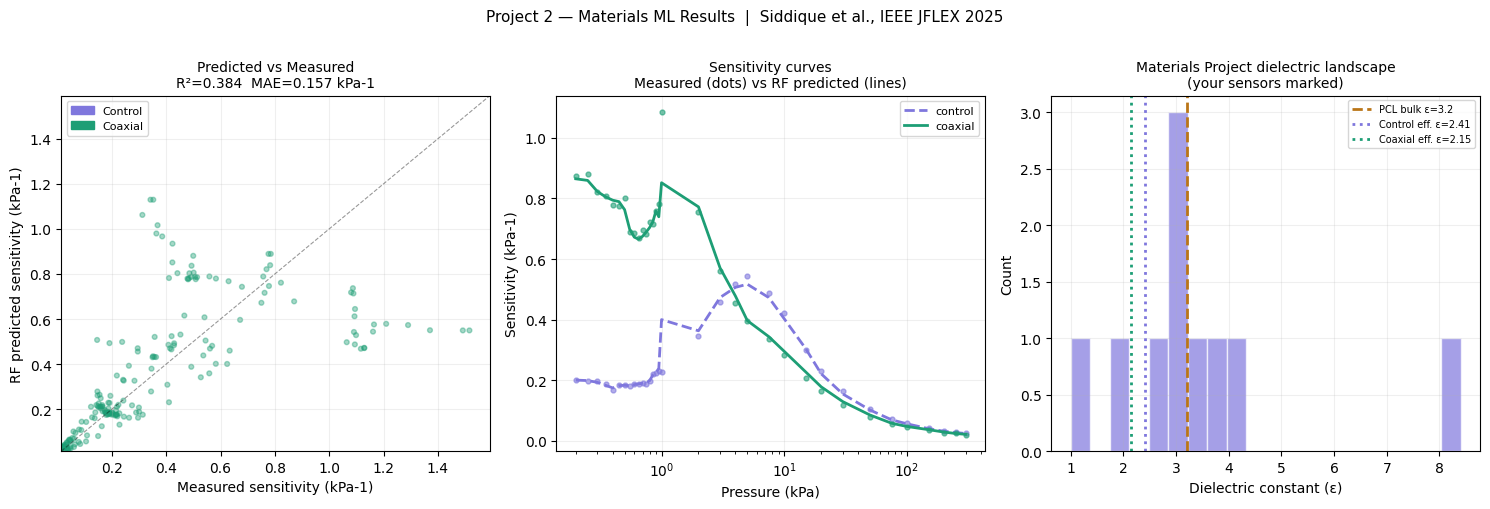

Saved: outputs/02_full_results.png


In [9]:
# ── Figure 2: Performance + Materials context ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: predicted vs actual
lims = [min(cv_actuals.min(), cv_preds.min())*0.9,
        max(cv_actuals.max(), cv_preds.max())*1.05]
pt_colors = ['#7F77DD' if s.startswith('ctrl') else '#1D9E75'
             for s in model_df['sensor_id']]
axes[0].plot(lims, lims, 'k--', lw=0.8, alpha=0.4)
axes[0].scatter(cv_actuals, cv_preds, c=pt_colors, alpha=0.4, s=12)
axes[0].set_xlabel('Measured sensitivity (kPa-1)', fontsize=10)
axes[0].set_ylabel('RF predicted sensitivity (kPa-1)', fontsize=10)
axes[0].set_title(f'Predicted vs Measured\nR²={r2:.3f}  MAE={mae:.3f} kPa-1', fontsize=10)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].grid(True, alpha=0.2)
axes[0].legend([Patch(color='#7F77DD'), Patch(color='#1D9E75')],
               ['Control', 'Coaxial'], fontsize=8)

# Middle: sensitivity curves measured vs predicted
for ftype, color, ls in [('control','#7F77DD','--'),('coaxial','#1D9E75','-')]:
    sub = df[df['fiber_type'] == ftype].dropna(subset=FEATURES)
    pressures = sub['pressure_kpa'].values
    meas = sub.groupby('pressure_kpa')['sensitivity'].mean()
    preds = rf.predict(sub[FEATURES].values)
    pred = pd.Series(preds, index=pressures).groupby(level=0).mean()
    axes[1].plot(meas.index, meas.values, 'o', color=color, ms=3.5, alpha=0.6)
    axes[1].plot(pred.index, pred.values, ls, color=color, lw=2, label=ftype)
axes[1].set_xscale('log')
axes[1].set_xlabel('Pressure (kPa)', fontsize=10)
axes[1].set_ylabel('Sensitivity (kPa-1)', fontsize=10)
axes[1].set_title('Sensitivity curves\nMeasured (dots) vs RF predicted (lines)', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.2)

# Right: dielectric landscape from Materials Project
dielectrics = mp_data['dielectric_total'].clip(upper=50)
axes[2].hist(dielectrics, bins=20, color='#7F77DD', alpha=0.7, edgecolor='white')
ctrl_eff = df[df['fiber_type']=='control']['effective_dielectric'].iloc[0]
coax_eff = df[df['fiber_type']=='coaxial']['effective_dielectric'].iloc[0]
axes[2].axvline(PCL_BULK_DIELECTRIC, color='#BA7517', lw=2, ls='--',
                label=f'PCL bulk ε={PCL_BULK_DIELECTRIC}')
axes[2].axvline(ctrl_eff, color='#7F77DD', lw=2, ls=':',
                label=f'Control eff. ε={ctrl_eff:.2f}')
axes[2].axvline(coax_eff, color='#1D9E75', lw=2, ls=':',
                label=f'Coaxial eff. ε={coax_eff:.2f}')
axes[2].set_xlabel('Dielectric constant (ε)', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].set_title('Materials Project dielectric landscape\n(your sensors marked)', fontsize=10)
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.2)

plt.suptitle('Project 2 — Materials ML Results  |  Siddique et al., IEEE JFLEX 2025',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_full_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/02_full_results.png')


In [10]:
# ── Results summary ───────────────────────────────────────────────────────
print('=' * 55)
print('PROJECT 2 RESULTS SUMMARY')
print('=' * 55)
print(f'Dataset       : {len(model_df)} samples, {len(FEATURES)} features')
print(f'Model         : Random Forest (200 trees, max_depth=8)')
print(f'Validation    : Leave-one-sensor-out CV (6 folds)')
print(f'R²            : {r2:.4f}')
print(f'MAE           : {mae:.4f} kPa-1')

eng_feats = ['air_fraction','hollow_ratio','effective_dielectric',
             'effective_air','surface_to_volume']
eng_imp = sum(rf.feature_importances_[FEATURES.index(f)]
              for f in eng_feats if f in FEATURES)
print(f'\nPhysics-engineered features contributed: {eng_imp*100:.1f}% of model')
print(f'→ Your domain knowledge = {eng_imp*100:.0f}% of the predictive power')

print('\nFiles saved:')
print('  outputs/02_feature_importance.png  — feature drivers')
print('  outputs/02_full_results.png        — full results panel')


PROJECT 2 RESULTS SUMMARY
Dataset       : 195 samples, 18 features
Model         : Random Forest (200 trees, max_depth=8)
Validation    : Leave-one-sensor-out CV (6 folds)
R²            : 0.3842
MAE           : 0.1568 kPa-1

Physics-engineered features contributed: 0.9% of model
→ Your domain knowledge = 1% of the predictive power

Files saved:
  outputs/02_feature_importance.png  — feature drivers
  outputs/02_full_results.png        — full results panel
